# NIH ChestX-ray14 — Dataset Exploration & Analysis

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_ROOT = Path(r"C:\Users\mamou\.cache\kagglehub\datasets\nih-chest-xrays\data\versions\3")

# Master label/metadata file (one row per image, all 112,120 images)
df = pd.read_csv(DATA_ROOT / "Data_Entry_2017.csv")

print("Data_Entry_2017.csv:", df.shape)
print("columns:", list(df.columns))
df.head()

Data_Entry_2017.csv: (112120, 12)
columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [2]:
# Clean up the column names mangled by the CSV's bracketed headers + trailing comma
df = df.rename(columns={
    "OriginalImage[Width": "OriginalWidth",
    "Height]": "OriginalHeight",
    "OriginalImagePixelSpacing[x": "PixelSpacing_x",
    "y]": "PixelSpacing_y",
})
df = df.drop(columns=["Unnamed: 11"])

print("cleaned columns:", list(df.columns))
print("shape:", df.shape)
print("\ndtypes:")
print(df.dtypes)
print("\nnulls per column:")
print(df.isna().sum())

cleaned columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalWidth', 'OriginalHeight', 'PixelSpacing_x', 'PixelSpacing_y']
shape: (112120, 11)

dtypes:
Image Index           str
Finding Labels        str
Follow-up #         int64
Patient ID          int64
Patient Age         int64
Patient Gender        str
View Position         str
OriginalWidth       int64
OriginalHeight      int64
PixelSpacing_x    float64
PixelSpacing_y    float64
dtype: object

nulls per column:
Image Index       0
Finding Labels    0
Follow-up #       0
Patient ID        0
Patient Age       0
Patient Gender    0
View Position     0
OriginalWidth     0
OriginalHeight    0
PixelSpacing_x    0
PixelSpacing_y    0
dtype: int64


In [3]:
# Parse the pipe-separated "Finding Labels" into binary one-hot columns.
# NIH has 14 pathologies + the "No Finding" flag. Labels are clean binary (no uncertainty).
ALL_PATHOLOGIES = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass",
    "Nodule", "Pleural_Thickening", "Pneumonia", "Pneumothorax",
]
NO_FINDING = "No Finding"

# Split once, then build a 0/1 column per label
finding_sets = df["Finding Labels"].str.split("|")
for label in ALL_PATHOLOGIES + [NO_FINDING]:
    df[label] = finding_sets.apply(lambda s: int(label in s))

n = len(df)
counts = (
    df[ALL_PATHOLOGIES + [NO_FINDING]].sum()
      .sort_values(ascending=False)
      .rename("pos").to_frame()
)
counts["%of_all"] = (100 * counts["pos"] / n).round(2)
print(f"total images: {n}")
print("labels per image: min {}  max {}  mean {:.2f}".format(
    df[ALL_PATHOLOGIES].sum(axis=1).min(),
    df[ALL_PATHOLOGIES].sum(axis=1).max(),
    df[ALL_PATHOLOGIES].sum(axis=1).mean(),
))
counts

total images: 112120
labels per image: min 0  max 9  mean 0.72


,pos,%of_all
No Finding,60361,53.84
Infiltration,19894,17.74
Effusion,13317,11.88
Atelectasis,11559,10.31
Nodule,6331,5.65
Mass,5782,5.16
Pneumothorax,5302,4.73
Consolidation,4667,4.16
Pleural_Thickening,3385,3.02
Cardiomegaly,2776,2.48


In [4]:
# The 5 target tasks (shared with CheXpert). NIH calls "Pleural Effusion" simply "Effusion".
# We keep the NIH column name "Effusion" here; the CheXpert<->NIH name map is just for reference.
TARGET_TASKS = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion"]
CHEXPERT_NAME = {  # NIH name -> CheXpert name (same disease, different string)
    "Effusion": "Pleural Effusion",
}

n = len(df)
tt = df[TARGET_TASKS]

# Per-task prevalence
prev = tt.sum().rename("pos").to_frame()
prev["%pos"] = (100 * prev["pos"] / n).round(2)
print(f"total images: {n}")
print("\n5 target tasks — prevalence:")
print(prev)

# How the images distribute over the 5-task label space
n_pos_per_img = tt.sum(axis=1)
all_neg = int((n_pos_per_img == 0).sum())
any_pos = int((n_pos_per_img > 0).sum())
print(f"\nimages all-negative on the 5 tasks : {all_neg:>7d}  ({100*all_neg/n:.2f}%)")
print(f"images with >=1 of the 5 tasks pos : {any_pos:>7d}  ({100*any_pos/n:.2f}%)")

# Of the all-negative-on-5 images, how many are genuinely 'No Finding' vs positive only for the other 9?
all_neg_mask = n_pos_per_img == 0
no_finding_among_allneg = int(df.loc[all_neg_mask, NO_FINDING].sum())
other9_only = all_neg - no_finding_among_allneg
print(f"\nof those {all_neg} all-negative-on-5 images:")
print(f"   genuinely 'No Finding'        : {no_finding_among_allneg:>7d}")
print(f"   positive only for other-9 dx  : {other9_only:>7d}  (kept as valid negatives)")

total images: 112120

5 target tasks — prevalence:
                 pos   %pos
Atelectasis    11559  10.31
Cardiomegaly    2776   2.48
Consolidation   4667   4.16
Edema           2303   2.05
Effusion       13317  11.88

images all-negative on the 5 tasks :   84925  (75.74%)
images with >=1 of the 5 tasks pos :   27195  (24.26%)

of those 84925 all-negative-on-5 images:
   genuinely 'No Finding'        :   60361
   positive only for other-9 dx  :   24564  (kept as valid negatives)


In [5]:
# Official NIH split: train_val_list.txt + test_list.txt (these define the only official split;
# there is NO separate official validation set — we will carve val out of train_val in notebook 02).
train_val_list = (DATA_ROOT / "train_val_list.txt").read_text().split()
test_list      = (DATA_ROOT / "test_list.txt").read_text().split()
train_val_set, test_set = set(train_val_list), set(test_list)

print(f"train_val_list.txt : {len(train_val_list)} images ({len(train_val_set)} unique)")
print(f"test_list.txt      : {len(test_list)} images ({len(test_set)} unique)")
print(f"sum                : {len(train_val_list) + len(test_list)}  (== {len(df)} total: "
      f"{len(train_val_list) + len(test_list) == len(df)})")

# Tag each row with its official split
df["split"] = np.where(df["Image Index"].isin(train_val_set), "train_val",
              np.where(df["Image Index"].isin(test_set), "test", "MISSING"))
print("\nsplit counts:")
print(df["split"].value_counts(dropna=False))

# Patient-disjoint leakage check (NIH split is built per-patient, like CheXpert)
p_trainval = set(df.loc[df["split"] == "train_val", "Patient ID"])
p_test     = set(df.loc[df["split"] == "test",      "Patient ID"])
print(f"\npatients  train_val={len(p_trainval)}  test={len(p_test)}")
print(f"train_val ∩ test : {len(p_trainval & p_test)} shared  (must be 0)")

train_val_list.txt : 86524 images (86524 unique)
test_list.txt      : 25596 images (25596 unique)
sum                : 112120  (== 112120 total: True)

split counts:
split
train_val    86524
test         25596
Name: count, dtype: int64

patients  train_val=28008  test=2797
train_val ∩ test : 0 shared  (must be 0)


--- train_val: 86524 images ---
Gender: {'M': '48458 (56.0%)', 'F': '38066 (44.0%)'}
View  : {'PA': '56214 (65.0%)', 'AP': '30310 (35.0%)'}
Age   : min 1  max 413  mean 46.9  median 49
   age > 100 (bogus): 12   age == 0: 0

--- test: 25596 images ---
Gender: {'M': '14882 (58.1%)', 'F': '10714 (41.9%)'}
View  : {'AP': '14500 (56.6%)', 'PA': '11096 (43.4%)'}
Age   : min 1  max 414  mean 47.0  median 49
   age > 100 (bogus): 4   age == 0: 0



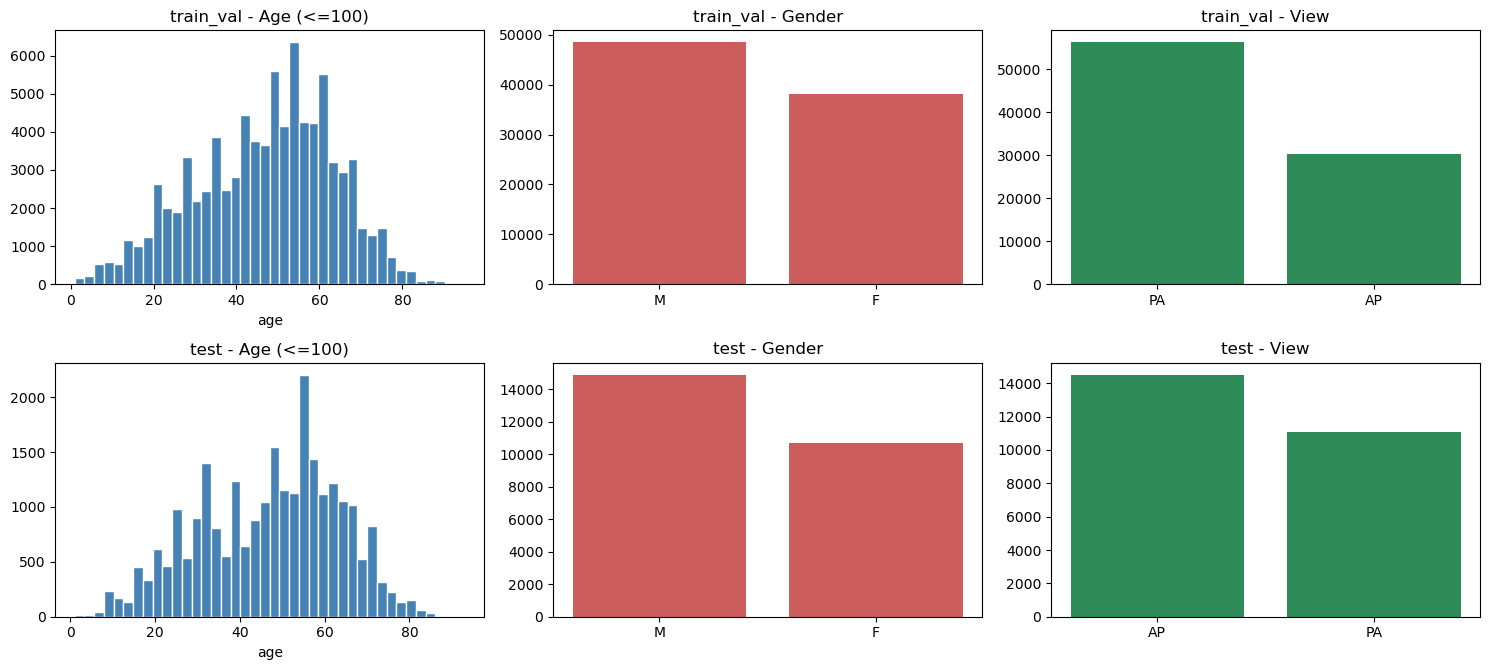

In [6]:
# Demographics (Age, Gender) and View Position (AP/PA) per official split.
# NIH ages are known to contain a few bogus values (>100) from de-identification artifacts.
import matplotlib.pyplot as plt

splits = [("train_val", df[df["split"] == "train_val"]), ("test", df[df["split"] == "test"])]

for name, d in splits:
    print(f"--- {name}: {len(d)} images ---")
    print("Gender:", {k: f"{v} ({100*v/len(d):.1f}%)" for k, v in d["Patient Gender"].value_counts().items()})
    print("View  :", {k: f"{v} ({100*v/len(d):.1f}%)" for k, v in d["View Position"].value_counts().items()})
    age = d["Patient Age"]
    print("Age   : min {:.0f}  max {:.0f}  mean {:.1f}  median {:.0f}".format(
        age.min(), age.max(), age.mean(), age.median()))
    print(f"   age > 100 (bogus): {(age > 100).sum()}   age == 0: {(age == 0).sum()}")
    print()

fig, axes = plt.subplots(len(splits), 3, figsize=(15, 3.4 * len(splits)))
for i, (name, d) in enumerate(splits):
    axes[i, 0].hist(d.loc[d["Patient Age"] <= 100, "Patient Age"], bins=40, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{name} - Age (<=100)"); axes[i, 0].set_xlabel("age")
    gc = d["Patient Gender"].value_counts()
    axes[i, 1].bar(gc.index.astype(str), gc.values, color="indianred"); axes[i, 1].set_title(f"{name} - Gender")
    vc = d["View Position"].value_counts()
    axes[i, 2].bar(vc.index.astype(str), vc.values, color="seagreen"); axes[i, 2].set_title(f"{name} - View")
plt.tight_layout(); plt.show()

Positives per task (train_val):
Atelectasis      8280
Cardiomegaly     1707
Consolidation    2852
Edema            1378
Effusion         8659

P(column | row) %  — given row-task positive, how often column-task is also positive:


,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion
Atelectasis,100.0,2.3,9.1,1.8,25.2
Cardiomegaly,11.2,100.0,3.7,3.2,35.8
Consolidation,26.5,2.2,100.0,3.3,26.7
Edema,10.5,4.0,6.7,100.0,25.2
Effusion,24.1,7.1,8.8,4.0,100.0


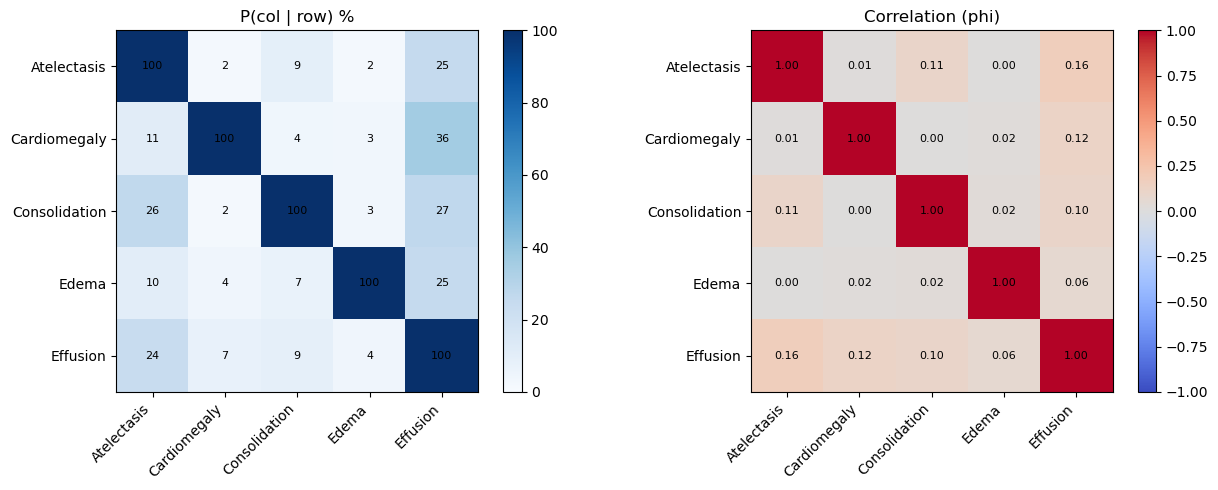

In [7]:
# Label co-occurrence among the 5 target tasks (TRAIN_VAL only; NIH labels are already binary 0/1)
tv = df[df["split"] == "train_val"]
Y = tv[TARGET_TASKS]

cooc = Y.T.dot(Y)                              # raw co-occurrence (diagonal = positives per task)
corr = Y.corr()                               # phi correlation between tasks
cooc_pct = (cooc.div(np.diag(cooc), axis=0) * 100).round(1)   # P(col | row) %

print("Positives per task (train_val):")
print(pd.Series(np.diag(cooc), index=TARGET_TASKS).to_string())
print("\nP(column | row) %  — given row-task positive, how often column-task is also positive:")
display(cooc_pct)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].imshow(cooc_pct, cmap="Blues", vmin=0, vmax=100); axes[0].set_title("P(col | row) %")
im1 = axes[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1);  axes[1].set_title("Correlation (phi)")
for ax in axes:
    ax.set_xticks(range(5)); ax.set_xticklabels(TARGET_TASKS, rotation=45, ha="right")
    ax.set_yticks(range(5)); ax.set_yticklabels(TARGET_TASKS)
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f"{cooc_pct.iloc[i,j]:.0f}", ha="center", va="center", fontsize=8)
        axes[1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046); fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

In [8]:
# One-time MERGE: move all PNGs from images_001..012/images/ into a single unified folder.
# Idempotent & safe to re-run: files already in IMAGES_DIR are left alone; collisions are detected.
import shutil

IMAGES_DIR = DATA_ROOT / "images"          # unified destination: ...\versions\3\images
IMAGES_DIR.mkdir(exist_ok=True)

partition_dirs = sorted(DATA_ROOT.glob("images_*/images"))

# --- BEFORE ---
before_partitions = {p.parent.name: len(list(p.glob("*.png"))) for p in partition_dirs}
before_unified = len(list(IMAGES_DIR.glob("*.png")))
total_before = sum(before_partitions.values())
print("BEFORE merge:")
for k, v in before_partitions.items():
    print(f"   {k:<12} {v:>6d}")
print(f"   {'unified':<12} {before_unified:>6d}")
print(f"   total in partitions: {total_before}")

# --- MOVE ---
moved, skipped = 0, 0
for pdir in partition_dirs:
    for src in pdir.glob("*.png"):
        dst = IMAGES_DIR / src.name
        if dst.exists():
            skipped += 1                    # already merged in a previous run
            continue
        shutil.move(str(src), str(dst))
        moved += 1
print(f"\nmoved: {moved}   skipped (already present): {skipped}")

# --- AFTER ---
after_unified = len(list(IMAGES_DIR.glob("*.png")))
leftover = {p.parent.name: len(list(p.glob('*.png'))) for p in partition_dirs}
leftover = {k: v for k, v in leftover.items() if v > 0}
print(f"\nAFTER merge:")
print(f"   unified folder count : {after_unified}  (expected {len(df)}: {after_unified == len(df)})")
print(f"   leftover in partitions: {leftover if leftover else 'none (all moved)'}")

# Every Image Index in the metadata must now exist in the unified folder
on_disk = {p.name for p in IMAGES_DIR.glob("*.png")}
missing = set(df["Image Index"]) - on_disk
print(f"   metadata images missing on disk: {len(missing)}")

BEFORE merge:
   images_001     4999
   images_002    10000
   images_003    10000
   images_004    10000
   images_005    10000
   images_006    10000
   images_007    10000
   images_008    10000
   images_009    10000
   images_010    10000
   images_011    10000
   images_012     7121
   unified           0
   total in partitions: 112120

moved: 112120   skipped (already present): 0

AFTER merge:
   unified folder count : 112120  (expected 112120: True)
   leftover in partitions: none (all moved)
   metadata images missing on disk: 0


In [9]:
# Clean up the now-empty partition folders (images_001 .. images_012).
# Guard: only remove a partition dir if it contains no .png files anywhere underneath.
removed = []
for pdir in sorted(DATA_ROOT.glob("images_*")):
    remaining = list(pdir.rglob("*.png"))
    if remaining:
        print(f"SKIP {pdir.name}: still has {len(remaining)} png(s)")
        continue
    shutil.rmtree(pdir)
    removed.append(pdir.name)

print("removed:", removed if removed else "nothing")
print("\nremaining images_* dirs:", [p.name for p in DATA_ROOT.glob("images_*")])
print("unified images folder count:", len(list(IMAGES_DIR.glob('*.png'))))

removed: ['images_001', 'images_002', 'images_003', 'images_004', 'images_005', 'images_006', 'images_007', 'images_008', 'images_009', 'images_010', 'images_011', 'images_012']

remaining images_* dirs: []
unified images folder count: 112120


In [10]:
# Image inspection: actual on-disk PNG dimensions / channel mode / intensity range (sampled).
# NOTE: the released NIH PNGs are resampled to 1024x1024; the OriginalWidth/Height columns are the
# pre-resampling DICOM sizes (e.g. 2682x2749), so those two are EXPECTED to differ.
from PIL import Image

SAMPLE_N = 4000
rng = np.random.default_rng(0)
sample_files = rng.choice(df["Image Index"].to_numpy(), size=SAMPLE_N, replace=False)

sizes, modes, gmin, gmax = [], [], [], []
for fname in sample_files:
    with Image.open(IMAGES_DIR / fname) as im:
        sizes.append(im.size)            # (width, height)
        modes.append(im.mode)
        arr = np.asarray(im)
        gmin.append(int(arr.min())); gmax.append(int(arr.max()))

ws = [s[0] for s in sizes]; hs = [s[1] for s in sizes]
print(f"sampled {SAMPLE_N} on-disk PNGs:")
print(f"   width  : min {min(ws)}  max {max(ws)}  median {int(np.median(ws))}")
print(f"   height : min {min(hs)}  max {max(hs)}  median {int(np.median(hs))}")
print(f"   unique (w,h) pairs : {sorted(set(sizes))}")
print(f"   channel modes      : {pd.Series(modes).value_counts().to_dict()}")
print(f"   intensity range    : global min {min(gmin)}  global max {max(gmax)}")

# Metadata original-resolution stats (the DICOM sizes, for reference)
print("\nmetadata OriginalWidth/Height (pre-resample DICOM sizes):")
print(f"   width  : min {df['OriginalWidth'].min()}  max {df['OriginalWidth'].max()}  median {int(df['OriginalWidth'].median())}")
print(f"   height : min {df['OriginalHeight'].min()}  max {df['OriginalHeight'].max()}  median {int(df['OriginalHeight'].median())}")
print(f"   distinct (w,h) original sizes: {df[['OriginalWidth','OriginalHeight']].drop_duplicates().shape[0]}")

sampled 4000 on-disk PNGs:
   width  : min 1024  max 1024  median 1024
   height : min 1024  max 1024  median 1024
   unique (w,h) pairs : [(1024, 1024)]
   channel modes      : {'L': 3979, 'RGBA': 21}
   intensity range    : global min 0  global max 255

metadata OriginalWidth/Height (pre-resample DICOM sizes):
   width  : min 1143  max 3827  median 2518
   height : min 966  max 4715  median 2544
   distinct (w,h) original sizes: 10471


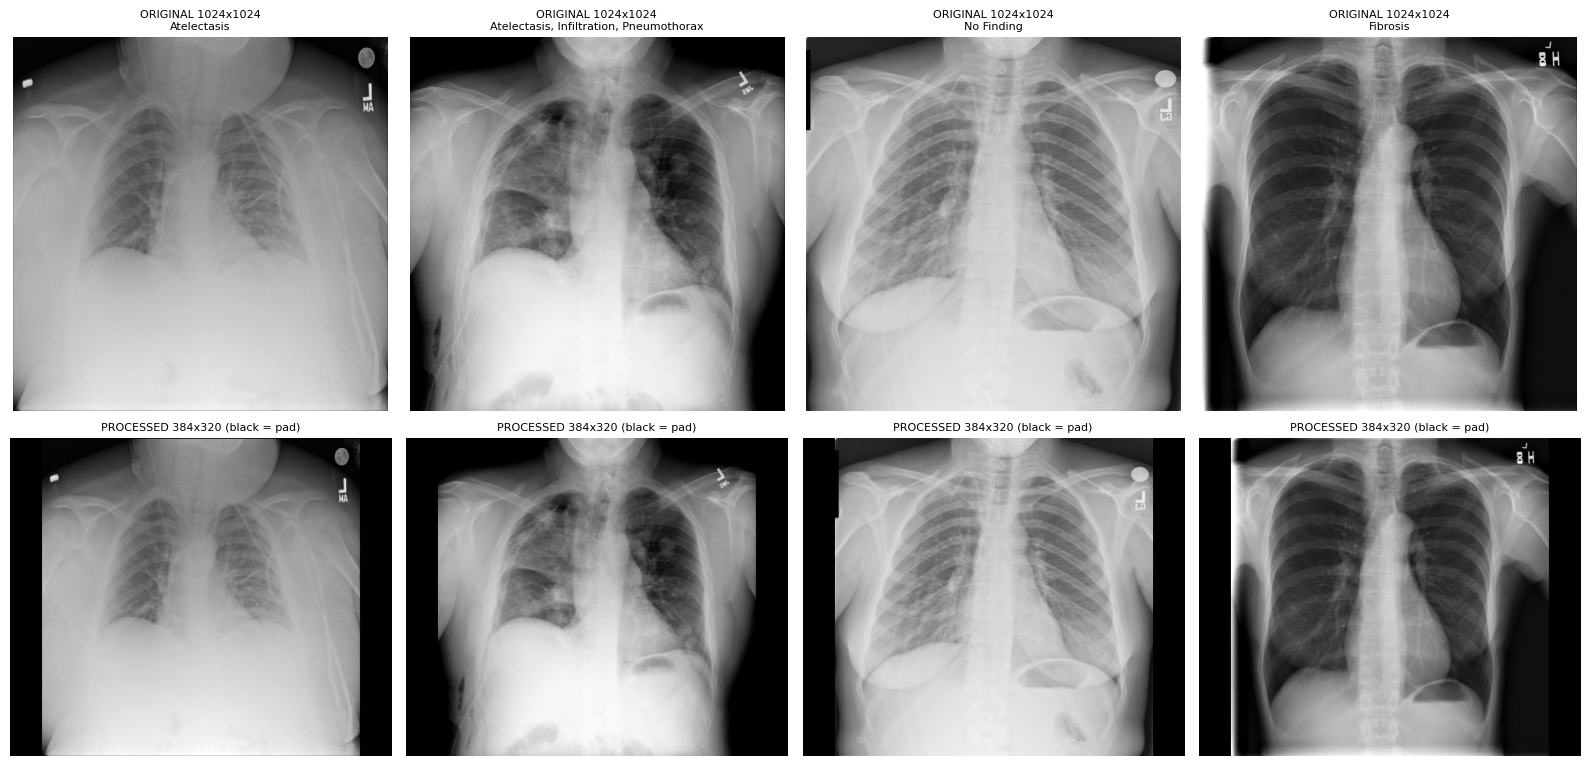

In [12]:
# Visual sanity check: native 1024x1024 -> aspect-preserving resize into 384x320 + center zero-pad.
# (No CLAHE here.) Confirms the chosen geometry looks right on NIH frontals.
import cv2

IMG_W, IMG_H = 384, 320

def resize_pad(img, out_w=IMG_W, out_h=IMG_H):
    h0, w0 = img.shape
    scale = min(out_w / w0, out_h / h0)
    new_w, new_h = max(1, round(w0 * scale)), max(1, round(h0 * scale))
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((out_h, out_w), dtype=img.dtype)
    top, left = (out_h - new_h) // 2, (out_w - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = img
    return canvas

sample_idx = np.random.choice(df.index, size=4, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, i in enumerate(sample_idx):
    row = df.loc[i]
    img = np.asarray(Image.open(IMAGES_DIR / row["Image Index"]).convert("L"))
    proc = resize_pad(img)
    pos = [c for c in ALL_PATHOLOGIES if row[c] == 1]
    axes[0, col].imshow(img, cmap="gray"); axes[0, col].axis("off")
    axes[0, col].set_title(f"ORIGINAL {img.shape[1]}x{img.shape[0]}\n" + (", ".join(pos) if pos else "No Finding"), fontsize=8)
    axes[1, col].imshow(proc, cmap="gray"); axes[1, col].axis("off")
    axes[1, col].set_title("PROCESSED 384x320 (black = pad)", fontsize=8)
plt.tight_layout(); plt.show()

## Summary — NIH ChestX-ray14

- **112,120 images**, 1024×1024 grayscale PNGs (≈0.5% stored as RGBA → forced to `L` in preprocessing). All **frontal only** (PA 60%, AP 40%); no laterals.
- **Labels**: 14 pathologies + `No Finding`, multi-label, clean binary (no uncertainty). Sparser than CheXpert.
- **Official split** (patient-disjoint, 0 leakage): `train_val` 86,524 imgs / 28,008 patients · `test` 25,596 imgs / 2,797 patients. **No official validation set** → carved in notebook 02.
- **5 target tasks** (shared with CheXpert; NIH `Effusion` = CheXpert `Pleural Effusion`): Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion. Low prevalence (2–12%); 75.7% of images are all-negative on the 5, of which 24,564 are positive only for the other 9 diseases — **kept as valid negatives**.
- **Images merged** from `images_001..012/` into a single unified `images/` folder; empty partition dirs removed.
- **Preprocessing geometry**: 1024² → aspect-preserving resize to 320×320 → center zero-pad to **384×320** (matches CheXpert exactly). ImageNet normalization + optional CLAHE handled in notebook 02.

→ Next: **`02_splits_dataset.ipynb`** — patient-grouped val carve-out, write split CSVs to `data/chestx_ray14/`, and the `Dataset` class.